In [3]:
# import packages
import pandas as pd
import statsmodels.api as sm
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# create dataframe with housing info and verify data import
df = pd.read_csv("D600 Task 3 Dataset 1 Housing Information.csv")
df

,ID,Price,SquareFootage,NumBathrooms,NumBedrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,...,RenovationQuality,LocalAmenities,TransportAccess,Fireplace,HouseColor,Garage,Floors,Windows,PreviousSalePrice,IsLuxury
0,4922,255614.8992,566.62,1.000000,4,779.42,20.56,5.62,39.46,10.08,...,4.93,4.44,4.55,Yes,Blue,No,1,13,181861.54230,0
1,5009,155586.0947,1472.34,1.000000,2,656.13,15.62,5.63,40.51,7.89,...,4.08,5.56,6.83,No,Green,No,1,17,50042.59757,0
2,4450,131050.8324,550.00,1.779354,3,754.57,12.47,9.20,48.38,23.74,...,4.26,8.07,8.48,Yes,Green,Yes,2,34,48400.34440,0
3,1070,151361.7125,941.81,2.035254,2,439.59,22.22,7.08,94.67,5.22,...,4.45,5.00,6.27,Yes,Red,No,1,14,84594.12145,0
4,400,113167.6128,550.00,1.064644,3,353.03,8.28,5.93,16.80,43.13,...,3.36,5.46,6.99,No,White,Yes,1,21,22934.59654,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,6987,307821.1758,550.00,2.111022,4,892.35,11.89,7.97,28.18,19.23,...,4.76,3.81,6.87,No,White,Yes,1,18,241131.63070,1
6996,6995,421368.8869,1726.12,4.056115,2,943.19,34.06,5.82,90.45,17.60,...,5.31,9.84,10.00,No,White,Yes,1,18,481604.80730,1
6997,6996,473382.5348,1026.36,2.077177,5,149.31,0.10,8.81,31.79,11.59,...,4.98,7.47,2.96,No,Green,No,1,13,380555.49390,1
6998,6998,343397.9756,2218.22,1.000000,4,526.81,11.18,9.20,15.21,3.96,...,4.68,7.66,6.12,No,Blue,Yes,1,10,442610.31710,0


In [5]:
# define continuous variables for pca
cvar = df[['SquareFootage', 'NumBathrooms', 'BackyardSpace','CrimeRate', 'SchoolRating', 'AgeOfHome',
            'DistanceToCityCenter', 'EmploymentRate', 'PropertyTaxRate', 'RenovationQuality', 'LocalAmenities',
            'TransportAccess', 'PreviousSalePrice']]

# standardize and export the data
scaler = StandardScaler()
cvar_scaled = scaler.fit_transform(cvar)
scaled_df = pd.DataFrame(cvar_scaled, columns = cvar.columns)
scaled_df.to_csv('Scaled Data.csv', index = False)

In [6]:
# describe the dependent variable
df['Price'].describe()

count    7.000000e+03
mean     3.072820e+05
std      1.501734e+05
min      8.500000e+04
25%      1.921075e+05
50%      2.793230e+05
75%      3.918781e+05
max      1.046676e+06
Name: Price, dtype: float64

In [7]:
# describe the independent variables
print(cvar.describe())

       SquareFootage  NumBathrooms  BackyardSpace    CrimeRate  SchoolRating  \
count    7000.000000   7000.000000    7000.000000  7000.000000   7000.000000   
mean     1048.947459      2.131397     511.507029    31.226194      6.942923   
std       426.010482      0.952561     279.926549    18.025327      1.888148   
min       550.000000      1.000000       0.390000     0.030000      0.220000   
25%       660.815000      1.290539     300.995000    17.390000      5.650000   
50%       996.320000      1.997774     495.965000    30.385000      7.010000   
75%      1342.292500      2.763997     704.012500    43.670000      8.360000   
max      2874.700000      5.807239    1631.360000    99.730000     10.000000   

         AgeOfHome  DistanceToCityCenter  EmploymentRate  PropertyTaxRate  \
count  7000.000000           7000.000000     7000.000000      7000.000000   
mean     46.797046             17.475337       93.711349         1.500437   
std      31.779701             12.024985        

In [8]:
# apply pca
pca = PCA(n_components = None)
cvar_pca_all = pca.fit_transform(cvar_scaled)

In [9]:
# create the matrix of all principal components
loadings_matrix = pca.components_.T
num_components = loadings_matrix.shape[1]
pc_names = [f'PC{i + 1}' for i in range(num_components)]
loadings_df = pd.DataFrame(loadings_matrix, index = cvar.columns, columns = pc_names)
print(loadings_df)

                           PC1       PC2       PC3       PC4       PC5  \
SquareFootage         0.355053  0.192905  0.243117  0.068597  0.011815   
NumBathrooms          0.306842  0.206168  0.231782  0.029927  0.078356   
BackyardSpace         0.103614 -0.011389 -0.099095 -0.089521  0.967412   
CrimeRate            -0.121532  0.024764  0.596005  0.004683  0.059147   
SchoolRating          0.384345  0.087609 -0.228961  0.153557 -0.153734   
AgeOfHome            -0.152288  0.068004  0.156310  0.604301  0.106024   
DistanceToCityCenter -0.211674 -0.039570  0.065883  0.493164  0.126068   
EmploymentRate        0.139473 -0.008550 -0.582676  0.354862  0.016240   
PropertyTaxRate      -0.156649 -0.060134  0.148363  0.419589 -0.037351   
RenovationQuality     0.431320  0.068575 -0.002215  0.218630 -0.038417   
LocalAmenities        0.213736 -0.658439  0.106656  0.037748 -0.008392   
TransportAccess       0.216714 -0.655512  0.104244  0.038288 -0.001334   
PreviousSalePrice     0.464633  0.1845

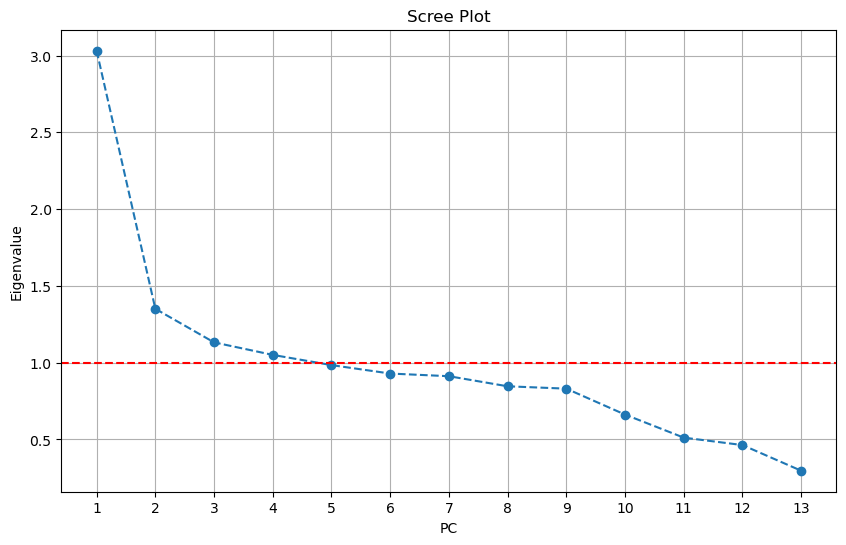

In [10]:
# get eigenvalues
eigenvalues = pca.explained_variance_

# make scree plot of eigenvalues
plt.figure(figsize = (10, 6))
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker = 'o', linestyle = '--')
plt.title('Scree Plot')
plt.xlabel('PC')
plt.ylabel('Eigenvalue')
plt.axhline(y = 1, color = 'r', linestyle = '--') # kaiser line
plt.xticks(range(1, len(eigenvalues) + 1))
plt.grid()
plt.show()

In [11]:
# print eigenvalues
eigenvalues

array([3.03147517, 1.35072947, 1.13224388, 1.05071455, 0.98422855,
       0.9293119 , 0.91196049, 0.84624217, 0.83090577, 0.66206516,
       0.51195829, 0.46356013, 0.29646189])

In [12]:
# create kaiser rule function
def kaiser_rule(eigenvalues):
    num_retain = np.sum(eigenvalues > 1)
    return num_retain

# apply kaiser rule
num_comp_kaiser = kaiser_rule(eigenvalues)
print(f'Number of components to retain with Kaiser Rule: {num_comp_kaiser}')

Number of components to retain with Kaiser Rule: 4


In [13]:
# apply pca with the selected components
pca_kaiser = PCA(n_components = num_comp_kaiser)
pca_kaiser.fit(cvar_scaled)

#get the explained variance ratio of the selected components
exvar_ratio_selected = pca_kaiser.explained_variance_ratio_

# print the variance ratio of the selected components
print(exvar_ratio_selected)

# get the explained variance ratio of all components
exvar_ratio_all = pca.explained_variance_ratio_

# print the variance ratio of all components
print(exvar_ratio_all)

[0.23315709 0.10388742 0.08708324 0.08081265]
[0.23315709 0.10388742 0.08708324 0.08081265 0.07569907 0.07147532
 0.07014079 0.06508625 0.0639067  0.05092081 0.03937578 0.03565338
 0.0228015 ]


In [14]:
# prep data for train test split
y = df['Price']
X = scaled_df

In [15]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

# create training dataset
train_df = pd.concat([X_train, y_train], axis = 1)

# create test dataset
test_df = pd.concat([X_test, y_test], axis = 1)

# export the datasets to csv
train_df.to_csv('Training_Data.csv', index = False)
test_df.to_csv('Testing_Data.csv', index = False)

In [16]:
# apply pca on scaled training data
pca = PCA(n_components = 4)
X_train_pca = pca.fit_transform(X_train)
X_train_pca_df = pd.DataFrame(X_train_pca, columns = [f'PC{i + 1}' for i in range(X_train_pca.shape[1])])

In [17]:
# transform scaled test data using fitted pca
X_test_pca = pca.transform(X_test)
X_test_pca_df = pd.DataFrame(X_test_pca, columns = [f'PC{i + 1}' for i in range(X_test_pca.shape[1])])

In [18]:
# combine pca with price for training
train_pca_df = pd.concat([X_train_pca_df, y_train.reset_index(drop = True)], axis = 1)

# combine pca with price for testing
test_pca_df = pd.concat([X_test_pca_df, y_test.reset_index(drop = True)], axis = 1)

In [19]:
# prep data for backward elimination
y_train_pca = train_pca_df['Price']
X_train_pca_be = train_pca_df.drop(columns = ['Price'])

In [20]:
# fit the initial linear regression and print
initial_model_pca = sm.OLS(y_train_pca, sm.add_constant(X_train_pca_be)).fit()
print(initial_model_pca.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.607
Method:                 Least Squares   F-statistic:                     2161.
Date:                Thu, 03 Apr 2025   Prob (F-statistic):               0.00
Time:                        19:28:24   Log-Likelihood:                -72128.
No. Observations:                5600   AIC:                         1.443e+05
Df Residuals:                    5595   BIC:                         1.443e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.086e+05   1269.341    243.103      0.0

In [21]:
# make predictions
y_pred_initial_pca = initial_model_pca.predict(sm.add_constant(X_test_pca_df))

In [22]:
# calculate mse before backward elimination
mse_before = mean_squared_error(y_test, y_pred_initial_pca)
print(mse_before)

8623375889.275692


In [23]:
# use backward elimination
def back_elim(X, y, sig_level = 0.05):
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    print(model.summary())
    p_values = model.pvalues
    while p_values.iloc[1:].max() > sig_level:
        rm_var = p_values.iloc[1:].idxmax()
        X = X.drop(columns = rm_var)
        model = sm.OLS(y, X).fit()
        p_values = model.pvalues
        print(model.summary())
    return model

fin_model_pca = back_elim(X_train_pca_be, y_train_pca)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.607
Method:                 Least Squares   F-statistic:                     2161.
Date:                Thu, 03 Apr 2025   Prob (F-statistic):               0.00
Time:                        19:28:24   Log-Likelihood:                -72128.
No. Observations:                5600   AIC:                         1.443e+05
Df Residuals:                    5595   BIC:                         1.443e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.086e+05   1269.341    243.103      0.0

In [24]:
# make predictions after optimization
X_train_pca_opt = X_train_pca_be[fin_model_pca.model.exog_names[1:]]
X_test_pca_opt = X_test_pca_df[fin_model_pca.model.exog_names[1:]]

# make predictions on training set
y_train_pred_pca = fin_model_pca.predict(sm.add_constant(X_train_pca_opt))

# make predictions on test set
y_test_pred_pca = fin_model_pca.predict(sm.add_constant(X_test_pca_opt))

In [25]:
# mse for training and test sets
mse_train_pca = mean_squared_error(y_train, y_train_pred_pca)
mse_test_pca = mean_squared_error(y_test, y_test_pred_pca)
print(f'Training MSE after BE: {mse_train_pca}')
print(f'Test MSE after BE: {mse_test_pca}')

Training MSE after BE: 9014814879.994297
Test MSE after BE: 8623375889.275692


In [26]:
# vif of original variables
vif_cvar = pd.DataFrame()
vif_cvar['Feature'] = cvar.columns
vif_cvar['VIF'] = [variance_inflation_factor(cvar.values, i) for i in range(cvar.shape[1])]
print(vif_cvar)

                 Feature        VIF
0          SquareFootage  11.223617
1           NumBathrooms   8.254357
2          BackyardSpace   4.423657
3              CrimeRate   4.081759
4           SchoolRating  21.268534
5              AgeOfHome   3.287388
6   DistanceToCityCenter   3.348290
7         EmploymentRate  53.737496
8        PropertyTaxRate  10.236303
9      RenovationQuality  12.319299
10        LocalAmenities   7.997519
11       TransportAccess  13.779965
12     PreviousSalePrice   7.815620


In [27]:
# vif after pca
vif_pca = pd.DataFrame()
vif_pca['Feature'] = X_train_pca_opt.columns
vif_pca['VIF'] = [variance_inflation_factor(X_train_pca_opt.values, i) for i in range(X_train_pca_opt.shape[1])]
print(vif_pca)

  Feature  VIF
0     PC1  1.0
1     PC2  1.0
2     PC3  1.0
3     PC4  1.0
